# 三個來源、三種粒度：對齊之前先看清楚資料

`streamlit_app.py` 把證交所股價、期交所未平倉、集保大戶持股放在同一頁，
理由是「這三條線合起來才看得出價格在動的時候籌碼往哪裡走」。

這本 notebook 檢查那個前提到底成不成立——結論會有點掃興，但它是誠實的，
而且**直接解釋了儀表板為什麼是三張獨立的圖，而不是一個合成指標**。

資料來源沿用 app.py 的規則：**有 `data/` 就用 `data/`，沒有才退回 `sample_data/`**。
`data/` 不納入版控，所以 fresh clone 或雲端跑到的是 35 KB 的展示快照；
本機跑過爬蟲之後這本 notebook 會自動改讀最新資料，不必改任何設定。


## 設定與載入


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR, SAMPLE_DIR = ROOT / "data", ROOT / "sample_data"

SURFACE, INK, INK_2, MUTED, GRID, AXIS = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Microsoft JhengHei", "Segoe UI", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK_2,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.edgecolor": AXIS,
    "font.size": 10,
})


def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)


def resolve_data_dir():
    """與 streamlit_app.py 的 resolve_data_dir() 同一套規則。"""
    if DATA_DIR.exists() and any(DATA_DIR.glob("*.csv")):
        return DATA_DIR, False
    return SAMPLE_DIR, True


ACTIVE_DIR, using_sample = resolve_data_dir()
print(f"資料來源：{ACTIVE_DIR.name}/"
      f"{'（版控內的展示快照）' if using_sample else '（本機爬蟲結果）'}")

# encoding 一律 utf-8-sig：三個來源的 CSV 都帶 UTF-8 BOM，
# 用 'utf-8' 讀的話第一欄欄名會變成 '\ufeff日期'，之後每一次欄位存取都會 KeyError。
read = lambda p: pd.read_csv(p, encoding="utf-8-sig", parse_dates=["日期"])
twse = read(next(ACTIVE_DIR.glob("twse_*.csv")))
taifex = read(next(ACTIVE_DIR.glob("taifex_*.csv")))
tdcc = read(next(ACTIVE_DIR.glob("tdcc_*.csv")))

for name, df in [("證交所 股價", twse), ("期交所 期貨", taifex), ("集保 持股分級", tdcc)]:
    print(f"  {name:12s} {df.shape[0]:>4} 列 × {df.shape[1]:>2} 欄   "
          f"{df.日期.min().date()} ~ {df.日期.max().date()}")


資料來源：sample_data/（版控內的展示快照）
  證交所 股價         58 列 × 11 欄   2026-06-01 ~ 2026-08-21
  期交所 期貨        150 列 × 18 欄   2026-07-20 ~ 2026-08-21
  集保 持股分級       199 列 ×  7 欄   2026-06-05 ~ 2026-08-21


## Q1 — 三個來源的「一列」各自代表什麼？

這是對齊之前最該問的問題。三個來源的列數差很多，但那不是因為時間長度不同，
而是因為**主鍵不一樣**。


In [2]:
for name, df in [("twse", twse), ("taifex", taifex), ("tdcc", tdcc)]:
    n_dates = df.日期.nunique()
    print(f"{name:7s} {len(df):>4} 列 / {n_dates:>3} 個相異日期 = 每日 {len(df) / n_dates:.1f} 列")

print()
print("taifex 同一天的多列是不同到期月份的契約：")
display(taifex.groupby("日期").size().value_counts().rename("天數").to_frame().T)
print("  到期月份(週別) 取值：", sorted(taifex["到期月份(週別)"].astype(str).unique()))
print()
print("tdcc 同一天的多列是不同持股級距：")
print("  級距數：", tdcc["持股/單位數分級"].nunique())


twse      58 列 /  58 個相異日期 = 每日 1.0 列
taifex   150 列 /  25 個相異日期 = 每日 6.0 列
tdcc     199 列 /  12 個相異日期 = 每日 16.6 列

taifex 同一天的多列是不同到期月份的契約：


,6
天數,25


  到期月份(週別) 取值： ['202608', '202609', '202610', '202611', '202612', '202703', '202706']

tdcc 同一天的多列是不同持股級距：
  級距數： 17


主鍵分別是：

| 來源 | 主鍵 | 一列的意義 |
|---|---|---|
| 證交所 | `日期` | 一個交易日的 OHLC 與成交量 |
| 期交所 | `日期` + `到期月份(週別)` | 一個交易日的**一支契約** |
| 集保 | `日期` + `持股/單位數分級` | 一個結算日的**一個級距** |

**期交所每天有 6 支契約在交易**（近月、次月、季月……），
所以「今天的未平倉量」不是一個數字——要先決定看哪一支。
儀表板取的是**近月契約**（到期月份最小者），因為它的流動性最高、最貼近現貨。

這也說明為什麼 `taifex` 有 150 列卻只涵蓋 25 個交易日。


## Q2 — 時間粒度差多少？三者的重疊區間有多長？


,相異日期數,起,迄,間隔中位(天),間隔眾數(天)
來源,,,,,
twse,58,2026-06-01,2026-08-21,1.0,1.0
taifex,25,2026-07-20,2026-08-21,1.0,1.0
tdcc,12,2026-06-05,2026-08-21,7.0,7.0


三者共同涵蓋的區間：2026-07-20 ~ 2026-08-21（33 個日曆天）


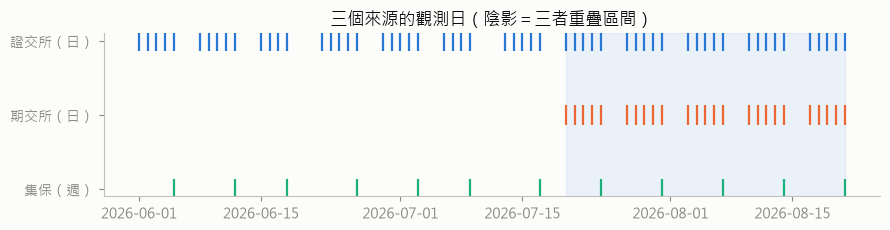

In [3]:
rows = []
for name, df in [("twse", twse), ("taifex", taifex), ("tdcc", tdcc)]:
    dates = pd.Series(sorted(df.日期.unique()))
    gaps = dates.diff().dt.days.dropna()
    rows.append({"來源": name, "相異日期數": len(dates),
                 "起": dates.min().date(), "迄": dates.max().date(),
                 "間隔中位(天)": gaps.median(), "間隔眾數(天)": gaps.mode().iloc[0]})
grain = pd.DataFrame(rows).set_index("來源")
display(grain)

lo = max(df.日期.min() for df in (twse, taifex, tdcc))
hi = min(df.日期.max() for df in (twse, taifex, tdcc))
print(f"三者共同涵蓋的區間：{lo.date()} ~ {hi.date()}（{(hi - lo).days + 1} 個日曆天）")

fig, ax = plt.subplots(figsize=(9, 2.4))
for i, (name, df) in enumerate([("集保（週）", tdcc), ("期交所（日）", taifex),
                                ("證交所（日）", twse)]):
    d = sorted(df.日期.unique())
    ax.plot(d, [i] * len(d), "|", markersize=14, markeredgewidth=1.6,
            color=["#1baf7a", "#eb6834", "#2a78d6"][i])
ax.axvspan(lo, hi, color="#2a78d6", alpha=0.08)
ax.set_yticks(range(3))
ax.set_yticklabels(["集保（週）", "期交所（日）", "證交所（日）"])
ax.set_title("三個來源的觀測日（陰影＝三者重疊區間）", color=INK)
style_axes(ax)
ax.grid(False, axis="y")
plt.tight_layout()
plt.show()


**集保是週頻的**（間隔眾數 7 天），另外兩個是日頻。
三者的重疊區間只有一個月出頭，而且瓶頸在期交所——這批快照只抓了最近一個月。

粒度不同帶來的是一個**真正的選擇**，不是技術細節：

- **內接（inner join）**：只留三者都有資料的日子，資料最乾淨但點數最少
- **前向填補（`merge_asof`）**：把最近一次的集保數字沿用到之後每個交易日，
  點數最多但等於假設「兩次結算之間籌碼沒有變」

Q5 會把兩種做法的實際可用點數算出來。


## Q3 — 集保資料裡的三個陷阱

這一節是這份資料最容易出錯的地方。三個陷阱都不會拋例外，只會讓數字悄悄錯掉。


In [4]:
levels = tdcc["持股/單位數分級"].value_counts()
print("級距與出現次數（共 %d 個相異值，日期數 %d）：" % (len(levels), tdcc.日期.nunique()))
display(levels.rename("出現次數").to_frame())


級距與出現次數（共 17 個相異值，日期數 12）：


,出現次數
持股/單位數分級,
"1,000,001以上",12
"1,000-5,000",12
1-999,12
"10,001-15,000",12
"100,001-200,000",12
"15,001-20,000",12
"20,001-30,000",12
"200,001-400,000",12
"30,001-40,000",12


**陷阱一：`合　計` 是一個「級距」。**
它混在其他級距裡，直接對整欄加總會把總數算兩次。而且注意那個名字——
`合　計` 中間是**全形空白**（U+3000），不是半形。用 `'合計'` 或 `'合 計'` 比對都不會命中，
而且不會報錯，只會安靜地漏掉。`streamlit_app.py` 為此把它定義成常數並加了註解。

**陷阱二：`差異數調整（說明4）` 只出現在部分日期，而且是負數。**
下面驗證它確實被算進 `合　計`。


In [5]:
adjust_mask = tdcc["持股/單位數分級"].str.startswith("差異數調整")
print(f"差異數調整出現 {adjust_mask.sum()} 次 / 共 {tdcc.日期.nunique()} 個結算日")
print("  取值：", tdcc.loc[adjust_mask, "股數/單位數"].tolist())

TOTAL_LEVEL = "合　計"  # 全形空白
check = []
for date, g in tdcc.groupby("日期"):
    total = g.loc[g["持股/單位數分級"] == TOTAL_LEVEL, "股數/單位數"]
    others = g.loc[g["持股/單位數分級"] != TOTAL_LEVEL, "股數/單位數"].sum()
    check.append({"日期": date.date(), "合計欄": int(total.iloc[0]),
                  "其餘列加總": int(others), "差": int(others - total.iloc[0])})
diff = pd.DataFrame(check)
print(f"\n合計 vs 其餘級距加總：{(diff['差'] == 0).sum()} / {len(diff)} 天完全相符")
display(diff.head(4))


差異數調整出現 7 次 / 共 12 個結算日
  取值： [-12981, -2000, -2000, -57875, -1000, -12000, -100]

合計 vs 其餘級距加總：12 / 12 天完全相符


,日期,合計欄,其餘列加總,差
0,2026-06-05,25932524521,25932524521,0
1,2026-06-12,25932370067,25932370067,0
2,2026-06-18,25932370067,25932370067,0
3,2026-06-26,25932370067,25932370067,0


`合　計` 與其餘級距（**含**差異數調整）的加總完全相符，一天不差。

所以差異數調整**不是**可以隨手丟掉的雜訊列：把它濾掉再加總，總數就對不上了。
它是負數（−100 到 −57,875 股），是集保為了讓級距總和等於實際庫存所做的平衡項。

**陷阱三：把級距當成可排序的數值。**
級距是字串（`"1,000,001以上"`、`"1-999"`），含逗號與中文，
排序時 `"1,000,001以上"` 會排在 `"1-999"` 前面。要比較大小必須自己解析成數值下界。


## Q4 — 缺值長什麼樣子？

三個來源的缺值成因完全不同，而且**每一種都不該用同樣的方式處理**。


In [6]:
for name, df in [("twse", twse), ("taifex", taifex), ("tdcc", tdcc)]:
    na = df.isna().sum()
    na = na[na > 0]
    if len(na):
        print(f"{name}：")
        for col, count in na.items():
            flag = "  ← 整欄皆空" if count == len(df) else ""
            print(f"    {col:12s} {count:>4} / {len(df)} 缺值（{count / len(df) * 100:>3.0f}%）{flag}")
    else:
        print(f"{name}：無缺值")


twse：
    註記             58 / 58 缺值（100%）  ← 整欄皆空
taifex：
    開盤價            11 / 150 缺值（  7%）
    最高價            16 / 150 缺值（ 11%）
    最低價            16 / 150 缺值（ 11%）
    最後成交價          11 / 150 缺值（  7%）
    漲跌價            11 / 150 缺值（  7%）
    漲跌%            11 / 150 缺值（  7%）
    結算價             1 / 150 缺值（  1%）
tdcc：
    人數              7 / 199 缺值（  4%）


### twse：`註記` 整欄都是空的

這不是抓取失敗——證交所的 `STOCK_DAY` API 固定回傳這個欄位，用來標記除權息、
暫停交易之類的事件，這段期間剛好什麼都沒發生。

**這是一個「現在沒用、但不能刪」的欄位**：一旦遇到除權息日，
它是唯一能解釋價格跳空的線索。爬蟲照抄來源欄位而不自作主張裁剪，在這種地方會回本。

### taifex：缺值全部集中在遠月契約

按「第幾近的契約」拆開看。


In [7]:
tx = taifex.assign(到期=taifex["到期月份(週別)"].astype(str))
tx["近月序"] = tx.groupby("日期")["到期"].rank(method="dense").astype(int)
by_rank = tx.groupby("近月序").agg(
    列數=("日期", "size"),
    開盤價缺=("開盤價", lambda s: s.isna().sum()),
    最高價缺=("最高價", lambda s: s.isna().sum()),
    成交量中位=("合計成交量", "median"),
    未平倉中位=("未沖銷契約量", "median"),
)
display(by_rank)

no_ohlc = tx[tx["開盤價"].isna()]
print(f"OHLC 缺失的 {len(no_ohlc)} 列，當天成交量：{sorted(no_ohlc['合計成交量'].tolist())}")
print(f"  其中『未沖銷契約量』仍有值：{no_ohlc['未沖銷契約量'].notna().sum()} / {len(no_ohlc)}")
print(f"  其中『結算價』仍有值：      {no_ohlc['結算價'].notna().sum()} / {len(no_ohlc)}")


,列數,開盤價缺,最高價缺,成交量中位,未平倉中位
近月序,,,,,
1,25,0,0,104241.0,103097.0
2,25,0,0,1391.0,6108.0
3,25,0,0,65.0,192.0
4,25,0,1,23.0,379.0
5,25,6,8,7.0,121.0
6,25,5,7,5.0,63.0


OHLC 缺失的 11 列，當天成交量：[0, 0, 0, 1, 2, 2, 3, 3, 4, 7, 9]
  其中『未沖銷契約量』仍有值：11 / 11
  其中『結算價』仍有值：      11 / 11


**近月契約（序 1）一格缺值都沒有，缺值全部落在序 4 以後。**
成交量中位數從近月的 10 萬口一路掉到第 6 近的 5 口——遠月契約當天根本沒什麼人交易，
沒有成交就沒有開高低收。

關鍵在最後兩行：**OHLC 缺失的那 11 列，`未沖銷契約量` 與 `結算價` 全都有值。**
未平倉是「目前有多少口部位還沒平掉」，是存量不是交易紀錄，沒成交也不會消失；
結算價則是交易所在無成交時依理論價計算的。

這正是儀表板**看未平倉而不看期貨價格**的理由：
未平倉在遠月契約上仍然可用，價格則會開天窗。

### tdcc：`人數` 的缺值精準對應 Q3 那個陷阱


In [8]:
missing_holders = tdcc[tdcc["人數"].isna()]
print(f"人數缺值 {len(missing_holders)} 列，全部是：",
      missing_holders["持股/單位數分級"].unique())
display(missing_holders[["日期", "持股/單位數分級", "人數", "股數/單位數"]])


人數缺值 7 列，全部是： <ArrowStringArray>
['差異數調整（說明4）']
Length: 1, dtype: str


,日期,持股/單位數分級,人數,股數/單位數
16,2026-06-05,差異數調整（說明4）,NaN,-12981
33,2026-06-12,差異數調整（說明4）,NaN,-2000
50,2026-06-18,差異數調整（說明4）,NaN,-2000
147,2026-07-31,差異數調整（說明4）,NaN,-57875
164,2026-08-07,差異數調整（說明4）,NaN,-1000
181,2026-08-14,差異數調整（說明4）,NaN,-12000
198,2026-08-21,差異數調整（說明4）,NaN,-100


`人數` 的缺值**完全落在 `差異數調整（說明4）` 這個級距上**，一列不多一列不少。

這合理：差異數調整是為了讓級距總和等於實際庫存所做的股數平衡項，
它沒有對應的「持有人」，所以人數欄本來就是空的。

**三種缺值、三種處理方式**——這是這一節的重點：

| 來源 | 缺值型態 | 該怎麼處理 |
|---|---|---|
| twse `註記` | 整欄皆空 | **保留**。它現在沒資訊，但除權息時是唯一線索 |
| taifex OHLC | 遠月契約無成交 | **不要補值**。改用同一列的未平倉／結算價，那兩欄沒缺 |
| tdcc `人數` | 結構性不存在 | **不是缺失**。這一列本來就沒有人數的概念 |

沒有一種適合用 `fillna(0)` 或 `dropna()` 一次帶過。


## Q5 — 對齊之後，還剩多少可用資料？

回到開頭那個前提：「三條線合起來才看得出籌碼往哪裡走」。
把三者接起來，看還剩幾個點可以支撐這個說法。


In [9]:
# 期貨取近月契約：到期月份最小者
near = (taifex.assign(到期=taifex["到期月份(週別)"].astype(str))
              .sort_values(["日期", "到期"])
              .groupby("日期", as_index=False).first())
major = (tdcc[tdcc["持股/單位數分級"] == "1,000,001以上"]
         [["日期", "占集保庫存數比例(%)"]].rename(columns={"占集保庫存數比例(%)": "大戶比例"}))

price_oi = twse[["日期", "收盤價"]].merge(near[["日期", "未沖銷契約量"]], on="日期")
inner = price_oi.merge(major, on="日期", how="inner")
asof = pd.merge_asof(price_oi.sort_values("日期"), major.sort_values("日期"),
                     on="日期", direction="backward")

print(f"股價 ∩ 期貨（皆日頻）           ：{len(price_oi):>3} 天")
print(f"再 ∩ 集保（內接，只留結算日）   ：{len(inner):>3} 天  ← 三源真正重合的點數")
print(f"改用 merge_asof 前向填補集保    ：{asof['大戶比例'].notna().sum():>3} 天"
      f"（但其中只有 {len(inner)} 天是新資訊）")

print("\n相關係數（僅供參考，見下方但書）：")
print(f"  收盤價 vs 未平倉（水準）  n={len(price_oi):>3}  r = "
      f"{price_oi['收盤價'].corr(price_oi['未沖銷契約量']):+.3f}")
print(f"  收盤價 vs 未平倉（日變動）n={len(price_oi) - 1:>3}  r = "
      f"{price_oi['收盤價'].diff().corr(price_oi['未沖銷契約量'].diff()):+.3f}")
print(f"  收盤價 vs 大戶比例（asof）n={len(asof):>3}  r = "
      f"{asof['收盤價'].corr(asof['大戶比例']):+.3f}")


股價 ∩ 期貨（皆日頻）           ： 25 天
再 ∩ 集保（內接，只留結算日）   ：  5 天  ← 三源真正重合的點數
改用 merge_asof 前向填補集保    ： 25 天（但其中只有 5 天是新資訊）

相關係數（僅供參考，見下方但書）：
  收盤價 vs 未平倉（水準）  n= 25  r = -0.133
  收盤價 vs 未平倉（日變動）n= 24  r = +0.117
  收盤價 vs 大戶比例（asof）n= 25  r = +0.071


**三個來源真正重合的只有 5 個點。**

`merge_asof` 看起來把可用天數推回 25 天，但那是假象——填補進去的值只有 5 個相異數字，
其餘 20 天是複製品。統計上的有效樣本數仍然是 5。

三個相關係數都落在 ±0.15 以內，而在 n=5 到 n=25 的規模下，
這個量級的相關**與 0 無法區分**。誠實的結論是：

> **這批 35 KB 的展示快照不足以回答「價格在動的時候籌碼往哪裡走」。**
> 要回答它，得先跑爬蟲把 `data/` 補到至少涵蓋數個季度的集保結算日。

這不是資料品質有問題，是**樣本量的問題**——`sample_data/` 的用途本來就只是
「讓雲端儀表板有東西可看」，README 也是這樣寫的。


## 小結：這份 EDA 解釋了儀表板的三個設計決定

| 觀察 | 對應的設計 |
|---|---|
| 三個來源主鍵不同，期交所每天 6 支契約 | 儀表板固定取**近月契約**，而不是把當日所有契約加總 |
| 集保是週頻、另兩者是日頻，重疊區間短 | 儀表板畫**三張獨立的圖**，不做跨來源的合成指標——因為對齊之後點數不足以支撐 |
| 大戶比例的實際變動只有 85.42% → 84.62%，不到 1 個百分點 | 折線圖的 y 軸刻意 `zero=False`。從 0 畫起會把這條線壓成一條直線，等於什麼都沒表達 |

另外三個「不會報錯但會讓數字錯掉」的陷阱，動這份資料之前要先知道：

1. `合　計` 是級距之一，且中間是**全形空白**——整欄加總會重複計算，用半形空白比對會安靜漏掉
2. `差異數調整（說明4）` 只出現在部分結算日、值為負，**且已包含在合計內**，濾掉會讓總數對不上
3. 級距是字串，直接排序會得到 `"1,000,001以上"` 排在 `"1-999"` 前面

**這本 notebook 的所有數字都來自 `sample_data/`（35 KB 展示快照）。**
本機跑過爬蟲後重跑，讀到的會是 `data/`，數字會不同但每一段的**問法**都成立。

重跑：`jupyter nbconvert --execute --inplace notebooks/eda.ipynb`（不需網路）。
